# Testing the draft 2D scatter plot (`new_graphics/scatter.py`)

This notebook exercises `make_scatter()`, the draft implementation of the new scatter
plot type. Plain scatter serves the Continuous x Continuous cell of the 2D lookup
table; the `jitter="orderly"` mode (sections 5–6) serves the Discrete x Discrete cell.
It is **not** wired into `.plot()` yet — this is for visually checking the draft before
integration. Scatter targets small simulations — the lookup table will select it only
when `n <= 40` (`SCATTER_MAX_N`) — so every example below uses n = 40.

**How to run:** use the `symbulate` conda environment (the draft imports helpers from
`symbulate.plot`, which is only installed there), then Run All. The setup cell finds the
repo root on its own, so it doesn't matter which folder Jupyter was launched from — and
it reloads `scatter.py` every time it runs, so after editing the draft just Run All
again; no kernel restart needed. Its printout shows which constants are loaded, so you
can confirm the kernel matches the file.

**What to look for in every plot:**
- Filled circles in the series color at alpha 0.25, so overlapping points stay
  readable while a lone point still reads as solid (note: this overrides the
  finalized Visual Style Guide's *unfilled* scatter decision — flagged for the
  decision log)
- Light reference grid behind the points, both horizontal **and vertical**; no top
  or right spines
- Axes labeled "Variable 1" / "Variable 2" by default, overridable with
  `xlabel=` / `ylabel=`
- Overlays get distinct Okabe-Ito colors (sky blue first, then orange) and an
  automatic "Variable k" legend in the top right
- With `jitter="orderly"` (discrete data): coincident points form a tight compass
  cluster centered on their value's grid crossing — center first, then N/E/S/W on
  the grid lines, then the diagonals (NE, SE, NW, SW) — so each cluster reads as
  one shared value

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder holding symbulate/symbulate.mplstyle),
# so the notebook works no matter where Jupyter was launched from.
REPO_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helper and its per-plot-type constants. The reload makes
# re-running this cell pick up the latest scatter.py even in a kernel
# that already imported an older version -- no kernel restart needed
# while the draft is being iterated on.
import scatter

importlib.reload(scatter)
from scatter import make_scatter, SCATTER_ALPHA, SCATTER_MARKER_SIZE
from symbulate.plot import get_next_color

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Applied *after* the imports above: importing symbulate currently switches
# matplotlib back to the old seaborn/ggplot stylesheet (a Phase 2 item).
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"SCATTER_ALPHA = {SCATTER_ALPHA}, SCATTER_MARKER_SIZE = {SCATTER_MARKER_SIZE}")

SCATTER_ALPHA = 0.25, SCATTER_MARKER_SIZE = 40


## 1. Reproduce the approved prototype

A single scatter of two positively correlated continuous variables, matching the
prototype image: points trending up and to the right, x-axis "Variable 1",
y-axis "Variable 2", no legend (a lone scatter doesn't need one). The first
color in the cycle is sky blue (`#56B4E9`).

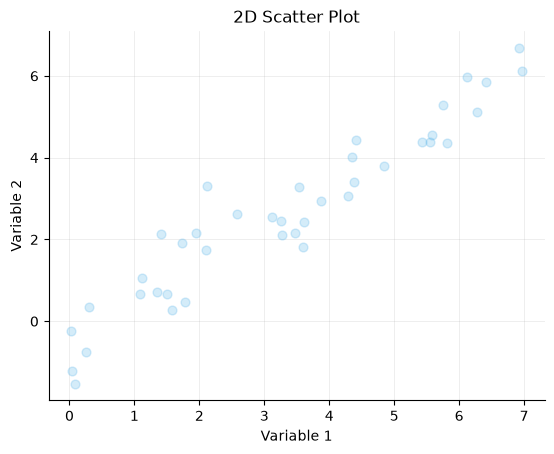

In [2]:
x = rng.uniform(0, 7, 40)
y = 0.8 * x + rng.normal(0, 0.8, 40)

ax = plt.gca()
make_scatter(x, y, ax, get_next_color(ax))
plt.show()

## 2. Options: transparency, custom axis and series labels

`alpha=` overrides the 0.25 default (useful for small samples, where fewer
points overlap); `xlabel=` / `ylabel=` rename the axes; `label=` names the
series in the legend once there is more than one.

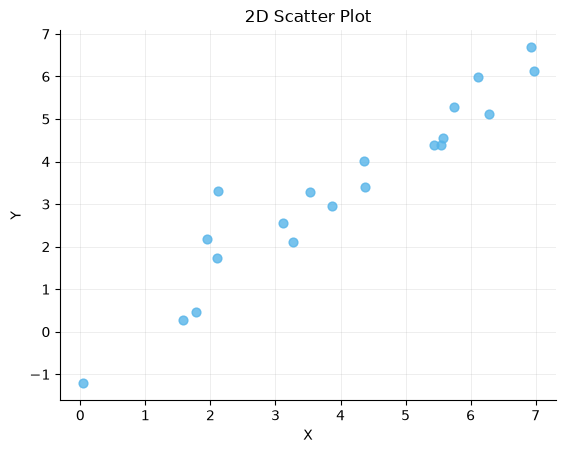

In [3]:
ax = plt.gca()
make_scatter(x[:20], y[:20], ax, get_next_color(ax), alpha=0.8, xlabel="X", ylabel="Y")
plt.show()

## 3. Overlay behavior — mimicking two `.plot()` calls

A second scatter on the same axes picks up the next Okabe-Ito color (orange)
and turns on the "Variable k" legend automatically. The open circles and low
alpha should keep the overlap region readable — you can still trace each cloud
through the other.

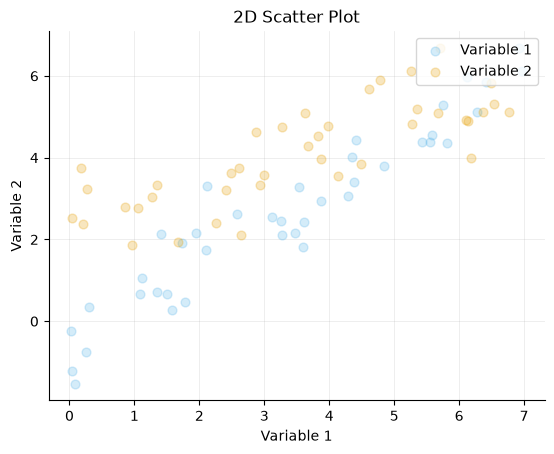

In [4]:
x2 = rng.uniform(0, 7, 40)
y2 = 0.5 * x2 + rng.normal(2.5, 0.8, 40)

ax = plt.gca()
make_scatter(x, y, ax, get_next_color(ax))
make_scatter(x2, y2, ax, get_next_color(ax))
plt.show()

## 4. With real symbulate simulation data

Same draft, but the data comes from an actual 2D `RV(...).sim(...)` call —
a bivariate normal with correlation 0.7, so the cloud should tilt clearly.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

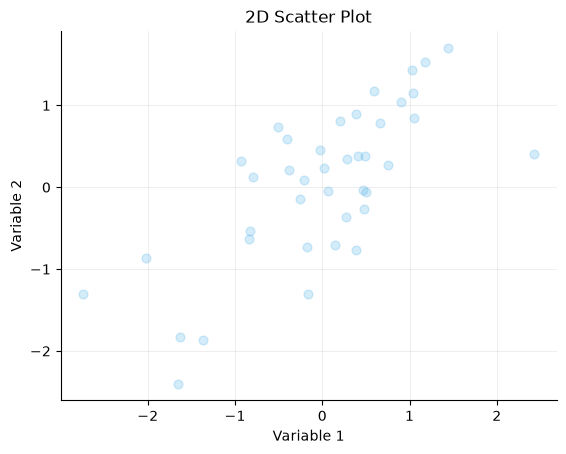

In [5]:
from symbulate import RV, BivariateNormal

sims = RV(BivariateNormal(mean1=0, mean2=0, sd1=1, sd2=1, corr=0.7)).sim(40)
arr = np.asarray(sims.results)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_scatter(arr[:, 0], arr[:, 1], ax, get_next_color(ax))
plt.show()

## 5. Discrete x Discrete: orderly jitter on the grid crossings

For two discrete variables, many points land on the exact same integer
`(x, y)`, so a plain scatter collapses them into one dot and random jitter
(`jitter=True`) scrambles the density. `jitter="orderly"` instead forms a tight
**compass cluster** centered on the value's grid crossing — the first point dead
center on the crossing, the next four on the grid lines at N/E/S/W, the next four
at the diagonals (NE, SE, NW, SW). The cluster hugs its crossing, so it reads as
one shared value (never as separate values) and you can read each value's density
by counting its dots.

Compare the two cells below: random jitter first, then orderly.

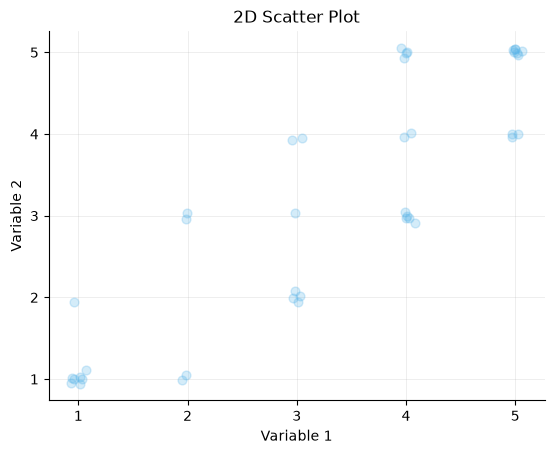

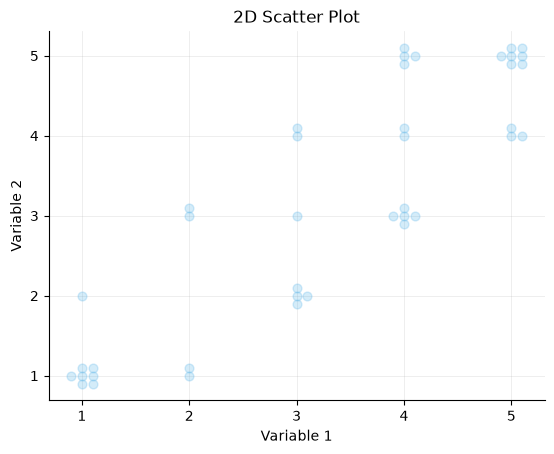

In [6]:
# Positively correlated integer data (e.g. two dependent discrete counts).
xd = rng.integers(1, 6, 40)
yd = np.clip(xd + rng.integers(-1, 2, 40), 1, 5)

# Random jitter: reduces overplotting but the density is impossible to read.
ax = plt.gca()
make_scatter(xd, yd, ax, get_next_color(ax), jitter=True)
plt.show()

# Orderly jitter: coincident points form tight countable compass clusters
# (center, then N/E/S/W, then the diagonals) sitting on the grid crossings.
ax = plt.gca()
make_scatter(xd, yd, ax, get_next_color(ax), jitter="orderly")
plt.show()

## 6. Orderly jitter on real symbulate discrete data

The discrete parallel of section 4: the data comes from an actual 2D discrete
`RV(...).sim(...)` — two independent `Binomial(6, 0.5)` counts, so probability
piles up in the central cells. With `jitter="orderly"`, the busy middle values
fill the countable compass cluster while the corner values hold just a point or two,
making the joint distribution's shape readable at a glance.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

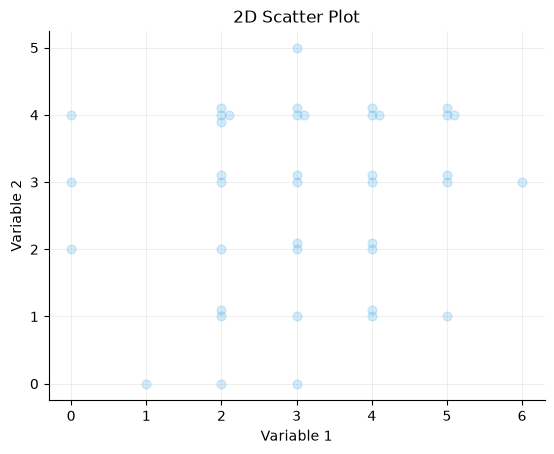

In [7]:
from symbulate import RV, Binomial

# Two independent Binomial(6, 0.5) counts -> a 2D discrete simulation.
disc_sims = RV(Binomial(6, 0.5) ** 2).sim(40)
disc = np.asarray(disc_sims.results)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_scatter(disc[:, 0], disc[:, 1], ax, get_next_color(ax), jitter="orderly")
plt.show()

## Verification checklist

- [ ] Section 1 matches the approved prototype image (sky blue, upward trend, no legend)
- [ ] Points are filled circles in the series color; overlap regions stay readable
- [ ] Grid behind the points, horizontal and vertical; no top/right spines
- [ ] `alpha=`, `xlabel=`, `ylabel=`, and `label=` overrides work
- [ ] Overlaid scatters get distinct Okabe-Ito colors and the automatic "Variable k" legend
- [ ] Works on real 2D `.sim()` output, not just numpy arrays
- [ ] Correlated bivariate normal data shows a clearly tilted cloud
- [ ] `jitter="orderly"`: grid lines pass through the cluster centers — every cluster sits on its own grid crossing
- [ ] Orderly clusters fill center-first, then N/E/S/W, then the diagonals, tight enough to read as one value; busy values are visibly fuller than sparse ones
- [ ] Orderly layout is deterministic — re-running gives the identical arrangement